In [ ]:
import os
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
LR = 0.001

transform = transforms.Compose([
            transforms.ToTensor(),  # Convert images to PyTorch tensors
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize images
        ])


# Incarca dataset-urile din folderul cu imagini (descarca mai intai imaginile)
train_dataset = torchvision.datasets.CIFAR10(root='/content/drive/MyDrive/data_cnn', train=True, transform=transform, download=False)
test_dataset = torchvision.datasets.CIFAR10(root='/content/drive/MyDrive/data_cnn', train=False, transform=transform, download=False)

# Cream data loader-e (imparte imaginile pe batch-uri)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
classes = ['plane', 'car', 'bird', 'deer', 'cat', 'dog', 'frog', 'horse', 'ship', 'truck']

<class 'torch.Tensor'>
6
frog


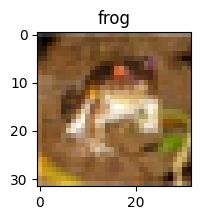

In [ ]:
image, label = train_dataset[0] # verificam prima imagine

print(type(image))   # <class 'PIL.Image.Image'>
print(label)         # 0, 1, ..., 9 (pozitii in classes, exemplu: 6 pentru frog)
print(classes[label])


plt.figure(figsize=(15, 2))


# Undo normalization: (x * std) + mean
# std - devierea standard, mean = media
unnorm = image * 0.5 + 0.5   # pt ca mean=0.5, std=0.5
plt.imshow(unnorm.permute(1, 2, 0))
plt.title(classes[label])
plt.show()

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # First convolutional layer: input channels=3 (RGB), output channels=32, kernel size=3x3, padding=1 to
        # preserve size
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)

        # Second convolutional layer: takes 32 feature maps, outputs 64, kernel size=3x3, padding=1
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        # Max pooling layer: reduces spatial dimensions by factor of 2
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layer: after two pools, CIFAR-10 (32x32) → 8x8 feature maps
        # 64 feature maps of size 8x8 = 64*8*8 = 4096 inputs
        self.fc1 = nn.Linear(64 * 8 * 8, 128)

        # Output layer: 128 → number of classes (10 for CIFAR-10)
        self.fc2 = nn.Linear(128, num_classes)

        # Folder path to save model checkpoints
        self.model_folder_path = './model'

    def forward(self, x):
        # Apply first convolution + ReLU, then pooling → output shape (32, 16, 16)
        x = self.pool(F.relu(self.conv1(x)))

        # Apply second convolution + ReLU, then pooling → output shape (64, 8, 8)
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten the tensor into a vector: (batch_size, 64*8*8 = 4096)
        x = x.view(x.size(0), -1)

        # Fully connected layer with ReLU → (batch_size, 128)
        x = F.relu(self.fc1(x))

        # Final fully connected layer (logits, not softmax) → (batch_size, num_classes)
        x = self.fc2(x)

        return x  # raw scores, CrossEntropyLoss will handle softmax internally

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu' # cand lucram local (cu Jupyter Lab)
# sau
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

In [ ]:
model = CNN(len(train_dataset.classes)).to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"Using device: {device}")

num_epochs = 20  # Define the number of epochs

for epoch in range(num_epochs):
    total_loss = 0.0

    for images, labels in train_loader:
        # Move data to the GPU
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()  # Zero the gradients
        outputs = model(images)  # Forward pass
        loss = loss_function(outputs, labels)  # Compute the loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update the weights

        total_loss += loss.item()

    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {total_loss / len(train_loader)}')


Using device: cuda
Epoch [1/20], Loss: 1.2752171864283826
Epoch [2/20], Loss: 0.9062716152068521
Epoch [3/20], Loss: 0.745112669883595
Epoch [4/20], Loss: 0.617462402046375
Epoch [5/20], Loss: 0.5057687287862989
Epoch [6/20], Loss: 0.40189012451310685
Epoch [7/20], Loss: 0.31610298329298114
Epoch [8/20], Loss: 0.24309714595171708
Epoch [9/20], Loss: 0.18803826178962119
Epoch [10/20], Loss: 0.1561431326121044
Epoch [11/20], Loss: 0.1301859665837232
Epoch [12/20], Loss: 0.11041149536150097
Epoch [13/20], Loss: 0.10070833617856194
Epoch [14/20], Loss: 0.0976963052804679
Epoch [15/20], Loss: 0.08322159240940813
Epoch [16/20], Loss: 0.08563649774270886
Epoch [17/20], Loss: 0.0697434470034398
Epoch [18/20], Loss: 0.07482147720362038
Epoch [19/20], Loss: 0.07138035856284357
Epoch [20/20], Loss: 0.07069905969087181


In [ ]:
model.eval()  # Set the model to evaluation mode
test_loss = 0.0
correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)  # Move images to the device
        labels = labels.to(device)  # Move labels to the device

        outputs = model(images)
        loss = loss_function(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()

test_loss /= len(test_loader)
accuracy = 100 * correct / len(test_loader.dataset)

print(f'Test Loss: {test_loss}, Accuracy: {accuracy}%')

Test Loss: 2.2606823465313775, Accuracy: 70.12%


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/data_cnn/model_jupyter.pth")

In [ ]:
trained_model = CNN(len(train_dataset.classes))
trained_model.load_state_dict(torch.load("/content/drive/MyDrive/data_cnn/model_jupyter.pth"))
trained_model.to(device) # mut modelul antrenat pe device

In [ ]:
from PIL import Image
import torch.nn.functional as F


new_transform = transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.ToTensor(),  # Convert images to PyTorch tensors
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize images
        ])

image_path = '/content/drive/MyDrive/imagini/three.jpg'
image = Image.open(image_path)
image = new_transform(image)
image = image.unsqueeze(0)  # Add a batch dimension

trained_model.eval()  # Set the model to evaluation mode
test_loss = 0.0
correct = 0

with torch.no_grad():
    # Move data to the GPU
    images = image.to(device)
    output = trained_model(images)
    # Apply softmax to get the probabilities
    probabilities = F.softmax(output, dim=1)
    _, predicted = torch.max(output, 1)

    index = predicted.item()
    predicted_label = classes[index]
    predicted_probability = probabilities[0][index].item()

    print(f'Predicted Label: {predicted_label}')
    print(f'Probability of Correct Prediction: {predicted_probability * 100:.2f}%')

Predicted Label: truck
Probability of Correct Prediction: 100.00%
